In [1]:
# Установка библиотеки YOLOv8
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.0 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.

100%|██████████| 6.25M/6.25M [00:00<00:00, 74.6MB/s]



0: 448x640 3 zebras, 2 giraffes, 356.8ms
Speed: 44.8ms preprocess, 356.8ms inference, 34.2ms postprocess per image at shape (1, 3, 448, 640)

0: 384x640 2 persons, 1 truck, 1 sheep, 163.5ms
Speed: 5.2ms preprocess, 163.5ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 352x640 1 bird, 2 dogs, 3 zebras, 2 giraffes, 2 kites, 156.3ms
Speed: 3.7ms preprocess, 156.3ms inference, 1.1ms postprocess per image at shape (1, 3, 352, 640)

0: 384x640 9 horses, 1 cow, 6 zebras, 145.7ms
Speed: 4.6ms preprocess, 145.7ms inference, 3.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 horse, 4 zebras, 2 giraffes, 142.2ms
Speed: 3.3ms preprocess, 142.2ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 448x640 1 person, 174.8ms
Speed: 4.8ms preprocess, 174.8ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)


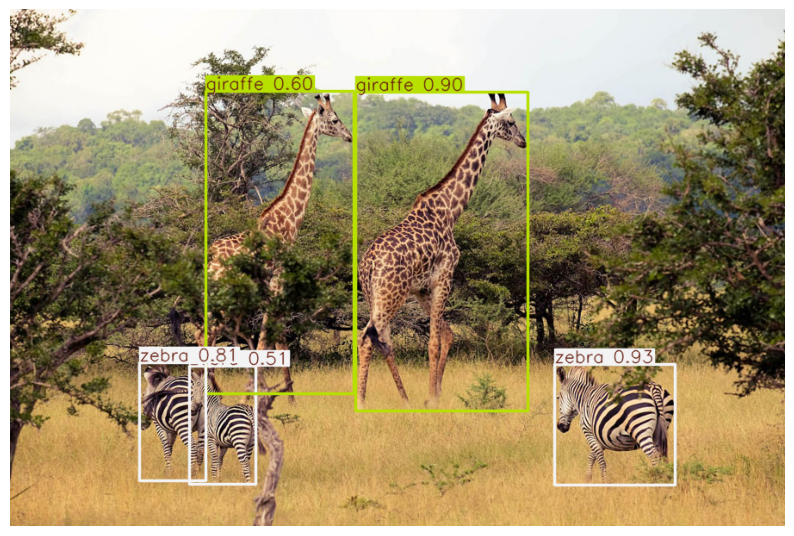

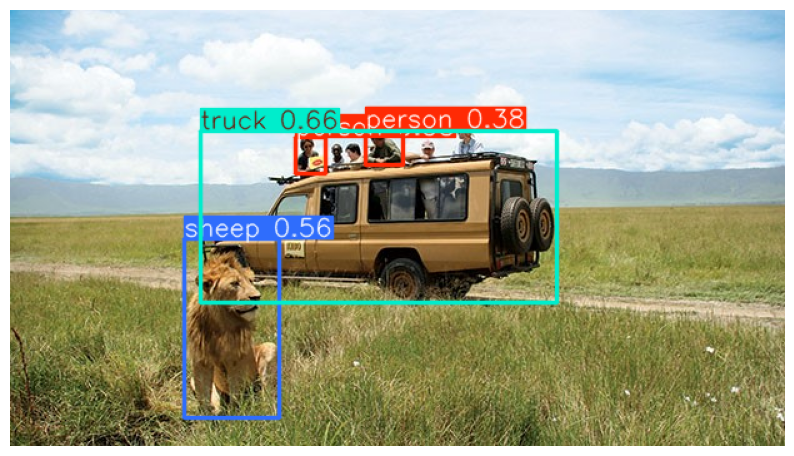

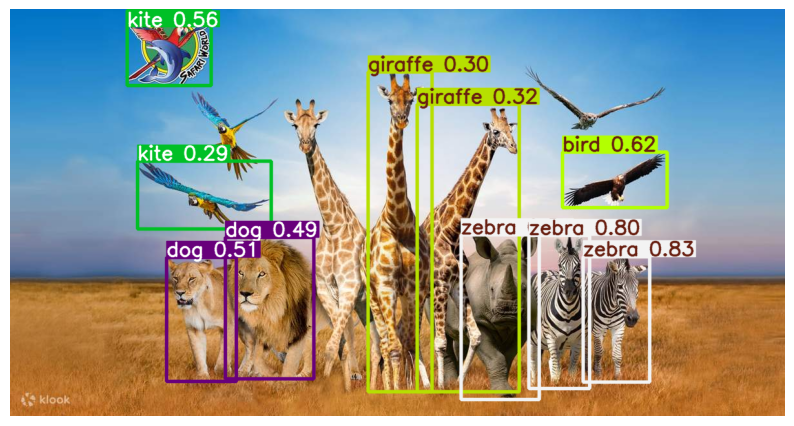

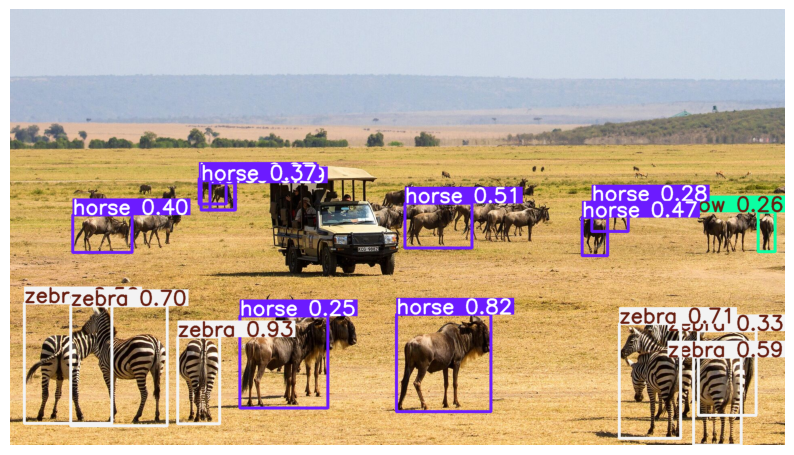

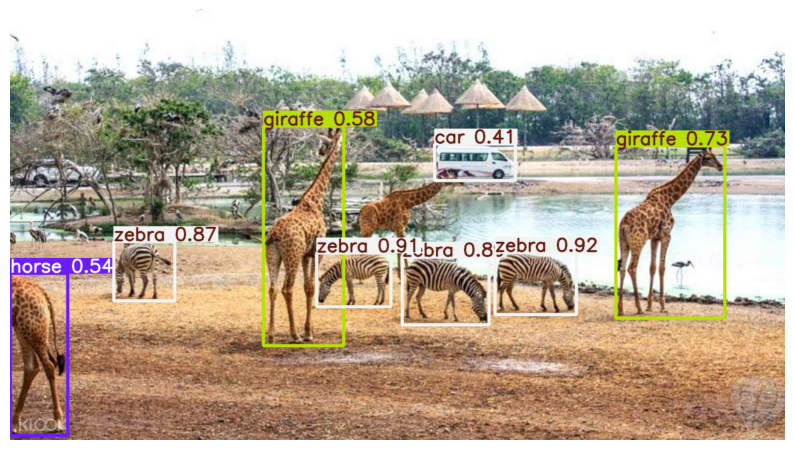

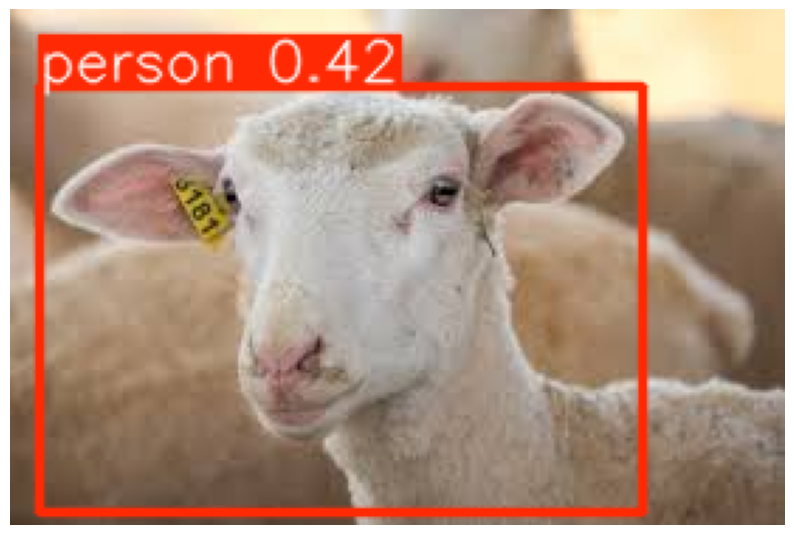

['results_yolo_0.jpg',
 'results_yolo_1.jpg',
 'results_yolo_2.jpg',
 'results_yolo_3.jpg',
 'results_yolo_4.jpg',
 'results_yolo_5.jpg']

In [2]:
import numpy as np
from PIL import Image
from ultralytics import YOLO
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

class YOLOTrain(BaseEstimator, TransformerMixin):
    def __init__(self, model_path="yolo-Weights/yolov8n.pt"):
        self.model_path = model_path
        self.model = YOLO(model_path)

    def predict(self, X):
        if self.model is None:
            raise ValueError("Модель не обучена")

        # Если X это список, обрабатываем каждый элемент
        if isinstance(X, list):
            results = [self.model.predict(np.array(Image.open(img_path)))[0] for img_path in X]
        else:
            img = Image.open(X)
            img_np = np.array(img)
            results = self.model.predict(img_np)[0]

        return results

    def save_new(self, y_pred, save_path='results_yolo'):
        # Сохранение результатов предсказания
        saved_paths = []
        if isinstance(y_pred, list):
            for i, result in enumerate(y_pred):
                im_array = result.plot()  # plot a BGR numpy array of predictions
                im = Image.fromarray(im_array)  # PIL image (correct colors)
                path = f"{save_path}_{i}.jpg"
                im.save(path)  # save image
                saved_paths.append(path)
        else:
            im_array = y_pred.plot()
            im = Image.fromarray(im_array)
            path = f"{save_path}.jpg"
            im.save(path)
            saved_paths.append(path)
        return saved_paths

    def show_image(self, y_pred):
        # Отображение результатов предсказания
        if isinstance(y_pred, list):
            for result in y_pred:
                im_array = result.plot()
                im = Image.fromarray(im_array)  # Преобразование BGR в RGB
                plt.figure(figsize=(10, 10))
                plt.imshow(im)
                plt.axis('off')
                plt.show()
        else:
            im_array = y_pred.plot()
            im = Image.fromarray(im_array)
            plt.figure(figsize=(10, 10))
            plt.imshow(im)
            plt.axis('off')
            plt.show()

# Создание пайплайна
pipe = Pipeline(steps=[
    ('neural_network_trainer', YOLOTrain())
])

# Использование пайплайна
image_paths = ['1.jpg','2.jpg','3.jpg','4.jpg','5.jpg', '6.jpg']  # Замените на путь к вашим изображениям
y_pred = pipe.named_steps['neural_network_trainer'].predict(image_paths)

# Отображение и сохранение результатов для каждого изображения
pipe.named_steps['neural_network_trainer'].show_image(y_pred)
pipe.named_steps['neural_network_trainer'].save_new(y_pred, 'results_yolo')